# Latent-variable models in practice

Fitting and evaluating mixtures, hierarchical and joint mixtures, HMMs, and LDA on data - with model selection (multi-restart, validation log-likelihood), component-trajectory diagnostics, and missing-field imputation. For how to construct each model, see the latent_variable_models tutorial.


## The latent-variable viewpoint

A latent-variable model introduces unobserved variables $z$ whose marginalization yields the observed
density, $p(x\mid\theta)=\int p(x,z\mid\theta)\,dz$ (or a sum in the discrete case). Mixtures, hidden
Markov models, and topic models are all of this form: $z$ is a component label, a hidden state, or a
topic assignment. The complete-data model $p(x,z\mid\theta)$ is simple; the observed-data likelihood,
with $z$ summed out, is the object we must maximize.

Theorem (EM and the evidence lower bound). For any distribution $q(z)$,
$\log p(x\mid\theta) = \mathcal F(q,\theta) + \mathrm{KL}(q\,\|\,p(z\mid x,\theta))$ with
$\mathcal F(q,\theta)=\mathbb E_q[\log p(x,z\mid\theta)]+\mathcal H(q)$. EM alternately maximizes
$\mathcal F$ over $q$ (E-step, closing the KL gap) and over $\theta$ (M-step), and never decreases the
likelihood (proved in the EM notebook). Variational methods restrict $q$ to a tractable family when the
exact posterior $p(z\mid x,\theta)$ is intractable.

This single identity organizes everything in this notebook: fitting a mixture, an HMM, or an LDA model is
the same coordinate ascent, differing only in the shape of $z$ and the form of the complete-data model.

## Identifiability, selection, and the inference of missing values

Identifiability. Latent-variable likelihoods are invariant to relabeling the latent states, so parameters
are identifiable only up to a permutation (label switching), and mixtures of identifiable component
families are otherwise identifiable up to that permutation (the density-estimation notebook). Summaries
that average across runs or posterior draws must first align the labels.

Model selection. The number of latent states (mixture components, HMM states, topics) is chosen by
penalized likelihood or held-out likelihood, not by the in-sample fit, which always improves with more
states. BIC and cross-validation (the model-selection notebook) apply directly.

Missing data by marginalization. Because the model is a joint density, a record with some fields missing
is scored by integrating the latent and the missing fields out; the posterior over the latent given the
observed fields imputes the rest. This is why the same fitted model both clusters and imputes, with no
separate imputation step.

Counterexamples to keep in view. The likelihood is multimodal, so EM finds a local optimum and needs
restarts; for continuous mixtures it is unbounded (a component can collapse onto a point); and the latent
labels carry no inherent meaning. All three were proved or shown in Modules 1 and 2, and they govern the
practical fitting choices made throughout this notebook.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


%matplotlib inline

In [2]:
from mixle.stats import *
from mixle.inference import initialize, estimate, seq_initialize, seq_estimate
from mixle.inference.estimation import optimize, best_of
from mixle.utils.evaluation import partition_data, empirical_kl_divergence
import mixle.utils.optsutil as ops

## Mixture Models

Mixture models are used to represent a finite collection of distinct behaviors. Mixtures are included in the area of unsupervised machine learning because knowledge of the unobserved mixture component is not directly observed but (mostly) inferrable from observed information.

Consider the following example that draws a 1000 samples from a mixture of two categorical distributions.


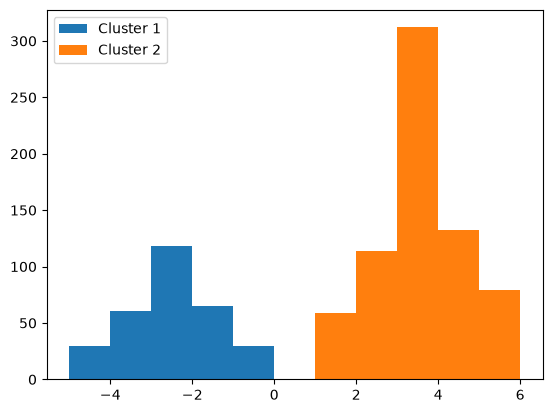

In [3]:
p = 0.3
rng = np.random.RandomState(1)

t1 = []
t2 = []
for i in range(1000):
    if rng.rand() <= p:
        t1.append(rng.choice([-5,-4,-3,-2,-1], p=np.divide([1,2,5,2,1],11)))
    else:
        t2.append(rng.choice([1,2,3,4,5], p=np.divide([1,2,5,2,1],11)))

        
fig,ax = plt.subplots()
ax.hist(t1, bins=range(-5,7), label='Cluster 1')
ax.hist(t2, bins=range(-5,7), label='Cluster 2')

ax.legend();

mixle supports mixtures through the `MixtureDistribution`  and `MixtureEstimator` classes. The `MixtureDistribution` class takes two arguments:
* `components` : A list of the components
* `w` : A list or ndarray containing the probability of drawing the corresponding component
`MixtureEstimator` takes a list of estimators for each mixture component.

If `components` is $[\ell_1, \ldots, \ell_N]$, then the complete data likelihood function is
$$\ell(-, z) = w[z] \cdot \ell_{z}(-)$$
and the likelihood function for the observed data is obtained by marginalizing out the latent state $z$
$$\ell(-) = \sum_{z = 1}^N w[z] \cdot \ell_{z}(-).$$


### Mixture Model - Gaussian Mixture

A mixture of 2D Gaussians is a good starting point. We'll start off with a simple three component model. The following makes a three component


In [4]:
rng = np.random.RandomState(1)

d1 = MultivariateGaussianDistribution([-8.0, -8.0], [[2.0, 1.0], [1.0, 2.0]])
d2 = MultivariateGaussianDistribution([ 0.0,  0.0], [[2.0, -1.0], [-1.0, 2.0]])
d3 = MultivariateGaussianDistribution([ 5.0,  1.0], [[2.0, 1.0], [1.0, 2.0]])
dist = ConditionalDistribution({1:d1, 2:d2, 3:d3}, given_dist=CategoricalDistribution({1:0.4, 2:0.4, 3:0.2}))
#dist = MixtureDistribution([d1, d2, d3], [0.4, 0.4, 0.2])

sampler = dist.sampler(seed=1)
data = sampler.sample(size=2000)

train_data, valid_data = partition_data(data, [0.8, 0.2], rng)

In [5]:
# strip the labels: the mixture is fit on the observations only
training_data = [u[1] for u in train_data]
validation_data = [u[1] for u in valid_data]

In [6]:
train_data[0]

(2, array([-1.66744382, -1.41961234]))

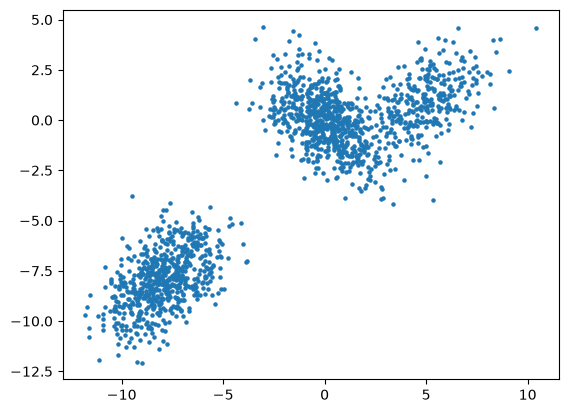

In [7]:
fig, ax = plt.subplots()

ax.scatter([u[0] for u in training_data], [u[1] for u in training_data], s=5)

The `MixtureEstimator` takes a list of estimators, one for each component. The following line is the estimator for a three component mixture of bivariate normal distributions.


In [8]:
# Specify a 3-component Gaussian mixture model
est = MixtureEstimator([MultivariateGaussianEstimator()]*3)

# Estimate maximum likelihood parameters
model = optimize(training_data, est, max_its=5000, print_iter=500)

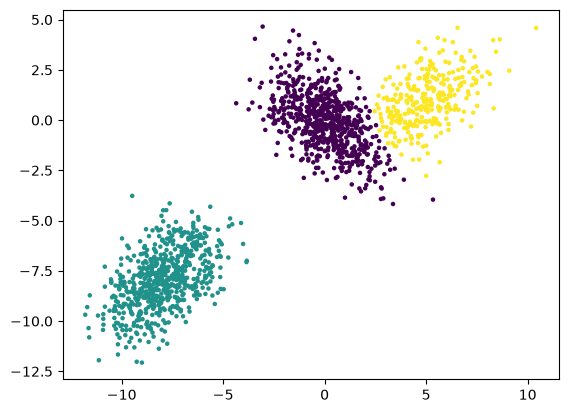

In [9]:
# Compute the most likely component for each observation
colors = [np.argmax(model.posterior(u)) for u in training_data]

plt.scatter([u[0] for u in training_data], [u[1] for u in training_data], c=colors, s=5)

We usually use some sort of validation data to perform model selection. The following line performs five random initializations using 10% of the data, each with at most 100 iterations, and running until the change in log-likelihood drops below 1.0e-6.


In [10]:
rng = np.random.RandomState(1)
_, dist_est = best_of(training_data, validation_data, est, 5, 100, 0.1, 1.0e-6, rng, print_iter=200)

/Users/grantboquet/mixle/.ci-repro-colima/candidate-081/venv/lib/python3.12/site-packages/mixle/inference/estimation.py:2170: UserWarning: optimize() stopped at the max_its cap (100) before the objective settled (last objective gain 0.000648, delta=1e-06): the returned model is an unconverged fit, and its fit_provenance() reports converged=False. Raise max_its to fit to convergence, or pass delta=None to request a fixed iteration count without this note.
  mm = optimize(


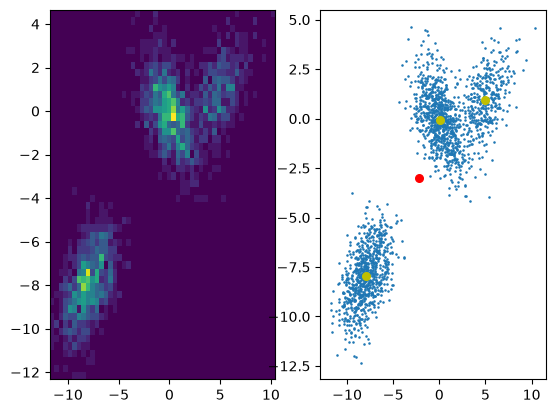

In [11]:
fig = plt.figure()
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)

mus = np.asarray([u.mu for u in dist_est.components])
data2 = np.asarray([u[1] for u in data])

ax1.hist2d(data2[:,0], data2[:,1], bins=50)
ax2.scatter(data2[:,0], data2[:,1], s=0.7)
ax2.scatter(np.mean(data2[:,0]), np.mean(data2[:,1]), c='r', s=30)
ax2.scatter(mus[:,0], mus[:,1], c='y', s=30);

The above example uses mixle's vectorized estimation. Alternatively, we could use the (much much slower) entry level estimation. We'll take this opportunity to monitor some of EM's visiable parts.


In [12]:
rng = np.random.RandomState(1)
model = initialize(training_data, est, rng, 0.1)

estimated_means = [[u.mu] for u in model.components]

vll = sum([model.log_density(u) for u in validation_data])
tll = sum([model.log_density(u) for u in training_data])

ll_history = [[vll, tll]]

print('Initialization: LL(train) = %f, LL(test) = %f'%(tll,vll))

for i in range(100):
    model = estimate(training_data, est, model)
    
    for j,u in enumerate(model.components):
        estimated_means[j].append(u.mu)
    
    vll = sum([model.log_density(u) for u in validation_data])
    tll = sum([model.log_density(u) for u in training_data])
    
    ll_history.append([vll, tll])
    if i % 10 == 0:
        print('Iteration %03d: LL(train) = %f, LL(test) = %f'%(i+1,tll,vll))

Initialization: LL(train) = -8300.848424, LL(test) = -2075.672143


Iteration 001: LL(train) = -8285.183756, LL(test) = -2070.588881


Iteration 011: LL(train) = -7360.483050, LL(test) = -1809.835870


Iteration 021: LL(train) = -7302.006622, LL(test) = -1792.605011


Iteration 031: LL(train) = -7255.128582, LL(test) = -1781.406776


...

Iteration 051: LL(train) = -7033.480337, LL(test) = -1735.478400


Iteration 061: LL(train) = -7025.407701, LL(test) = -1733.791534


Iteration 071: LL(train) = -7025.306245, LL(test) = -1733.746833


Iteration 081: LL(train) = -7025.305973, LL(test) = -1733.745555


Iteration 091: LL(train) = -7025.305972, LL(test) = -1733.745495


The most obvious statistic to diagnose convergence is the validation and training average log-densities. These were captured by the variable `ll_history`.


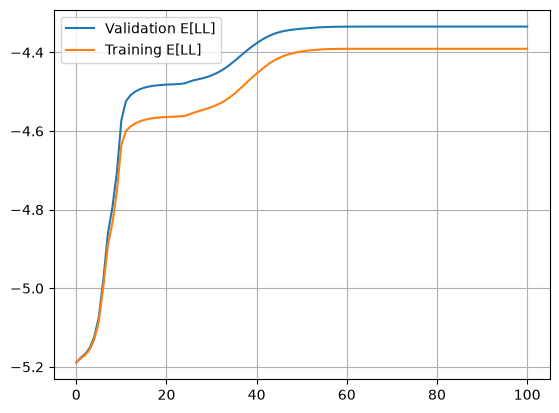

In [13]:
ll_history = np.asarray(ll_history)

fig = plt.figure()
ax = fig.add_subplot(111)

ax.plot(ll_history[:,0]/len(validation_data), label='Validation E[LL]')
ax.plot(ll_history[:,1]/len(training_data), label='Training E[LL]')
ax.legend()
ax.grid();

Another informative (and cool!) thing to observe are the trajectories of the components.


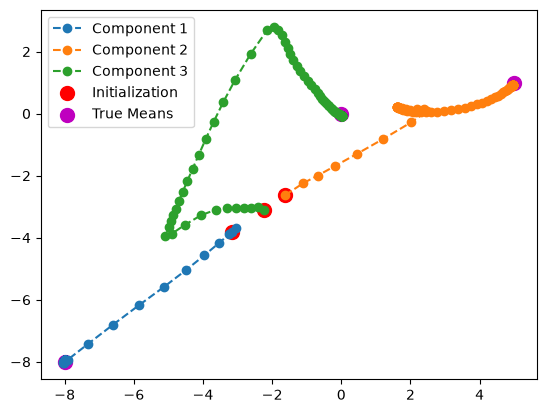

In [14]:
fig = plt.figure()
ax = fig.add_subplot(111)
fvals = np.zeros((3,2))
tvals = np.zeros((3,2))

for j,comp_history in enumerate(estimated_means):
    
    mu_history = np.asarray(comp_history)
    ax.plot(mu_history[:,0], mu_history[:,1], 'C%do--'%(j), label='Component %d'%(j+1))
    fvals[j,:] = [mu_history[0,0], mu_history[0,1]]
    
    # True distribution values
    tvals[j,:] = [d1, d2, d3][j].mu
    
ax.scatter(fvals[:,0], fvals[:,1], c='r', s=100, label='Initialization')
ax.scatter(tvals[:,0], tvals[:,1], c='m', s=100, label='True Means')

ax.legend();

### Mixture Model - Composite Mixture


Composite mixtures allow modeling heterogenous conditionally independent feature vectors. The following code creates samples from a three component mixture with features:

$$(\text{real number}, \text{a maybe missing string}, \text{a sequence of strings}, \text{a set of values})$$


In [15]:
rng = np.random.RandomState(1)

d10 = MixtureDistribution([GaussianDistribution(-10.0, 1.0), GaussianDistribution(0.0, 1.0)], [0.5, 0.5])
d11 = OptionalDistribution(GeometricDistribution(0.1), p=0.1)
d12 = MarkovChainDistribution({'a' : 0.5, 'b' : 0.5}, {'a' : { 'a' : 0.2, 'b' : 0.8}, 'b' : { 'a' : 0.8, 'b' : 0.2}}, len_dist=PoissonDistribution(8.0))
d13 = BernoulliSetDistribution({'a' : 0.1, 'b': 0.3, 'c': 0.7, 'd':0.9})

d1  = CompositeDistribution([d10, d11, d12, d13])

d20 = MixtureDistribution([GaussianDistribution(10.0, 1.0), GaussianDistribution(5.0, 1.0)], [0.5, 0.5])
d21 = OptionalDistribution(GeometricDistribution(0.2), p=0.2)
d22 = MarkovChainDistribution({'a': 0.5, 'b': 0.5}, {'a': {'a': 0.8, 'b': 0.2}, 'b': {'a': 0.2, 'b': 0.8}}, len_dist=PoissonDistribution(8.0))
d23 = BernoulliSetDistribution({'a': 0.9, 'b': 0.8, 'c': 0.1, 'd': 0.1})

d2  = CompositeDistribution([d20, d21, d22, d23])


d30 = MixtureDistribution([GaussianDistribution(0.0, 1.0), GaussianDistribution(5.0, 1.0)], [0.5, 0.5])
d31 = OptionalDistribution(GeometricDistribution(0.9), p=0.01)
d32 = MarkovChainDistribution({'a': 0.8, 'b': 0.2}, {'a': {'a': 0.5, 'b': 0.5}, 'b': {'a': 0.2, 'b': 0.8}}, len_dist=PoissonDistribution(8.0))
d33 = BernoulliSetDistribution({'a': 0.5, 'b': 0.5, 'c': 0.5, 'd': 0.8})

d3  = CompositeDistribution([d30, d31, d32, d33])


dist = MixtureDistribution([d1, d2, d3], [0.4, 0.3, 0.3])

sampler = dist.sampler(seed=1)
data = sampler.sample(size=1000)

train_data, valid_data = partition_data(data, [0.8, 0.2], rng)

Here are some samples from our distribution:


In [16]:
print('\n'.join(['Sample %d: '%(i) + str(data[i]) for i in range(10)]))

Sample 0: (np.float64(0.6686303329964771), np.int64(2), ['a', 'b', 'a', 'a', 'a', 'b'], ['b', 'c', 'd'])
Sample 1: (np.float64(10.350647916171429), np.int64(3), ['a', 'a', 'a', 'b', 'b', 'b', 'b', 'b', 'b', 'b'], ['a', 'b'])
Sample 2: (np.float64(0.739563168142132), np.int64(1), ['a', 'a', 'a', 'a', 'a', 'b', 'b', 'b', 'b'], ['b', 'c', 'd'])
Sample 3: (np.float64(-0.2714997605268183), np.int64(5), ['b', 'b', 'b', 'a', 'b', 'a', 'b', 'a', 'b', 'a'], ['d'])
Sample 4: (np.float64(9.99793581013596), np.int64(2), ['b', 'b', 'b', 'b', 'b', 'b', 'b'], ['a'])
Sample 5: (np.float64(2.4818289083013707), np.int64(17), ['a', 'b', 'a', 'b', 'a', 'b', 'a', 'a', 'b', 'a'], ['b', 'c', 'd'])
Sample 6: (np.float64(3.5814342690219645), np.int64(2), ['a', 'a', 'b', 'b', 'b', 'a', 'b', 'b', 'a', 'b'], ['a', 'b', 'c', 'd'])
Sample 7: (np.float64(-10.458094237090492), np.int64(6), ['b', 'a', 'b', 'a', 'b', 'a', 'b', 'a'], ['b', 'c', 'd'])
Sample 8: (np.float64(2.777018107143461), np.int64(16), ['a', 'a', 'b'

Sometimes we just want only one estimate of the model (no retrials). In these setting we can use `optimize`, which checks for convergence using the log-likelihood (pass `delta=None` for a fixed number of EM steps with no convergence check).


In [17]:
rng = np.random.RandomState(1)

e0 = MixtureEstimator([GaussianEstimator()] * 2, pseudo_count=1.0)
e1 = OptionalEstimator(GeometricEstimator(), est_prob=True, pseudo_count=1.0)
e2 = MarkovChainEstimator(pseudo_count=1.0, len_estimator=PoissonEstimator())
e3 = BernoulliSetEstimator()
iest = MixtureEstimator([CompositeEstimator((e0, e1, e2, e3))] * 3, pseudo_count=1.0)

e0 = MixtureEstimator([GaussianEstimator()] * 2)
e1 = OptionalEstimator(GeometricEstimator(), est_prob=True)
e2 = MarkovChainEstimator(len_estimator=PoissonEstimator())
e3 = BernoulliSetEstimator()
est = MixtureEstimator([CompositeEstimator((e0, e1, e2, e3))] * 3)

#_, dist_est = best_of(train_data, valid_data, est, 5, 100, 0.1, 1.0e-6, rng, print_iter=20)

dist_est = optimize(data, est, max_its=500, rng=rng, print_iter=50, init_estimator=iest)

In [18]:
print(str(dist_est.components[0].dists[0]))
print(str(dist_est.components[1].dists[0]))
print(str(dist_est.components[2].dists[0]))

print(str(dist_est.components[0].dists[-1]))
print(str(dist_est.components[1].dists[-1]))
print(str(dist_est.components[2].dists[-1]))

MixtureDistribution([GaussianDistribution(-9.931029279597245, 0.8113535054502581, name=None, keys=None),GaussianDistribution(0.04800384867807563, 1.038295618140905, name=None, keys=None)], [np.float64(0.48584371537086574), np.float64(0.5141562846291342)], name=None)
MixtureDistribution([GaussianDistribution(0.6317463981126492, 5.546416115268737e-13, name=None, keys=None),GaussianDistribution(7.557698020259777, 7.03053699232161, name=None, keys=None)], [np.float64(0.0022931462365497384), np.float64(0.9977068537634503)], name=None)
MixtureDistribution([GaussianDistribution(-0.049818117163228016, 0.8810126715413764, name=None, keys=None),GaussianDistribution(4.924640042940998, 1.0542882413747248, name=None, keys=None)], [np.float64(0.47115038470108184), np.float64(0.5288496152989182)], name=None)
BernoulliSetDistribution(dict([('b', 0.315818713780866), ('c', 0.6881117827258295), ('d', 0.8998959842360527), ('a', 0.09771802642826434)]), min_prob=1e-128, name=None, keys=None)
BernoulliSetDis

### Mixture Model - Imputation

In the above problem many of the samples were missing the second component of the composite (the geometric part). The posterior probability over the hidden state, $P(Z=i|\text{observed features})$, can be used to compute the conditional probability over the missing values as follows

$$P(\text{unobserved features} | \text{observed features}) = \sum_{i = 1}^N P(\text{unobserved features}|Z=i)P(Z=i|\text{observed features})$$.

Depending upon the application (and the whether the variable is equipped with sufficient structure)


In [19]:
point = list(filter(lambda u: u[1] is None, data))[0]
posterior = dist_est.posterior(point)
print(str(point))
print(str(posterior))

(np.float64(4.225630964827229), None, ['a', 'a', 'a', 'a', 'a', 'b', 'b'], ['a', 'b'])
[2.65508384e-09 9.96131388e-01 3.86860973e-03]


Since distributions in question are geometric with parameters $p_i$ for $i = 1, \ldots, N$, the conditional distribution has an expected value of

$$ E[P(\text{unobserved features} | \text{observed features})] = \sum_{i = 1}^{N} P(Z = i | \text{observed data}) \frac{1}{p_{i}} $$

We can either sample this distribution to compute its expected value or compute it analytically.


In [20]:
missing_conditional = MixtureDistribution([u.dists[1].dist for u in dist_est.components], posterior)
est_mean = np.dot(missing_conditional.w, [1/u.p for u in missing_conditional.components])
print(est_mean)

5.049980020611002


In [21]:
sampler = missing_conditional.sampler(seed = 10)
samples = sampler.sample(size = 10000)
avgs = np.cumsum(samples)/np.arange(1,len(samples)+1)
print(avgs[-1])

5.0926


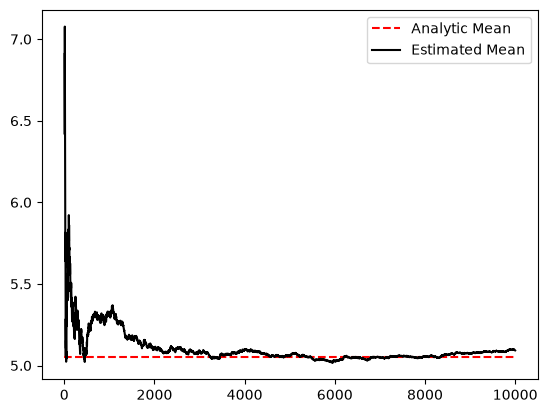

In [22]:
fig, ax = plt.subplots()

ax.plot([0,len(samples)], [est_mean]*2, '--r', label='Analytic Mean')
ax.plot(range(10,len(avgs)), avgs[10:], 'k', label='Estimated Mean')
ax.legend();

### Mixture Model - Mapping Heterogenous Data to the Simplex

Mixture models also provide a mapping of heterogenous data to a real vector: the posterior probability vector.


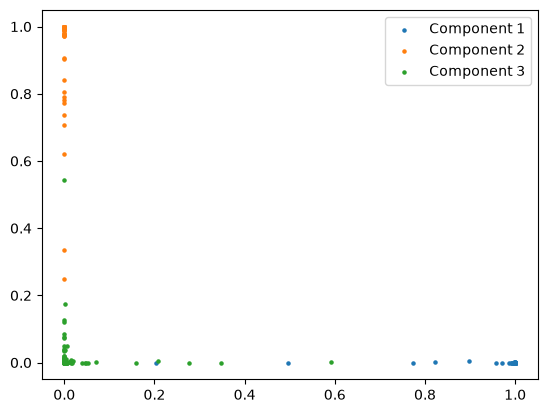

In [23]:
s1 = d1.sampler(seed=123).sample(size=100)
s2 = d2.sampler(seed=124).sample(size=100)
s3 = d3.sampler(seed=125).sample(size=100)

posterior1 = np.asarray([dist_est.posterior(u) for u in s1])
posterior2 = np.asarray([dist_est.posterior(u) for u in s2])
posterior3 = np.asarray([dist_est.posterior(u) for u in s3])

# Another way of doing this:
# posterior1 = dist_est.seq_posterior(dist_est.dist_to_encoder().seq_encode(s1))

fig = plt.figure()
ax = fig.add_subplot(111)

ax.scatter(posterior1[:,0], posterior1[:,1], s=5, label='Component 1')
ax.scatter(posterior2[:,0], posterior2[:,1], s=5, label='Component 2')
ax.scatter(posterior3[:,0], posterior3[:,1], s=5, label='Component 3')

ax.legend();

## Hierarchical Mixture Models

Hierarchical mixtures are mixtures of mixtures. They are useful for modeling a collection of mixtures that share the same components. We'll cover here the two routes in mixle for specifying or estimating hierarchical mixture models.

The `HierarchicalMixtureDistribution` constructor takes three necessary arguments and an optional length argument:
* `topics`: a list of distributions
* `w`: a list mixing weights for the outer mixture
* `taus`: a matrix of mixing weights for the inner mixture
* `len_dist`: a distribution for the length of each sequence

The following is another way to specify a hierarchical mixture:

`mixtures = [SequenceDistribution(MixtureDistribution(topics, taus[i,:]), len_dist) for i in range(len(w))]`
`MixtureDistribution(mixtures, w)`


In [24]:
d1 = GaussianDistribution(-5.0, 1.0)
d2 = GaussianDistribution( 0.0, 1.0)
d3 = GaussianDistribution( 5.0, 1.0)

# Each row of this matrix contains the mixing weights for a mixture over [d1,d2,d3]
taus = [[0.34, 0.33, 0.33], [0.8, 0.1 ,0.1], [0.1, 0.8 ,0.1], [0.1, 0.1 ,0.8]]

# This is the probability of each of the above rows
w = [0.4, 0.2, 0.2, 0.2]

model = HierarchicalMixtureDistribution([d1,d2,d3], w, taus, len_dist=CategoricalDistribution({5:1.0}))

In [25]:
data = model.sampler(seed=1).sample(1000)

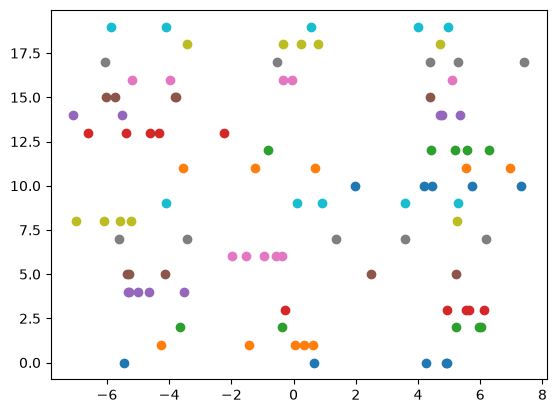

In [26]:
fig, ax = plt.subplots()

for i,u in enumerate(data[:20]):
    ax.scatter(u, [i]*len(u))

The estimator `HierarchicalMixtureEstimator` takes two necessary arguments:
* `estimators`: a list of estimators for the topics
* `num_mixtures`: the number of topic mixtures


In [27]:
est = HierarchicalMixtureEstimator([GaussianEstimator()]*3, 4)

model_v1 = optimize(data, est, 200, rng=np.random.RandomState(1), print_iter=10)

/var/folders/4k/23vz9g1x43nfgwlsdx7036hc0000gn/T/ipykernel_71354/3771694855.py:3: UserWarning: optimize() stopped at the max_its cap (200) before the objective settled (last objective gain 6.08e-09, delta=1e-09): the returned model is an unconverged fit, and its fit_provenance() reports converged=False. Raise max_its to fit to convergence, or pass delta=None to request a fixed iteration count without this note.
  model_v1 = optimize(data, est, 200, rng=np.random.RandomState(1), print_iter=10)


In [28]:
print('\n'.join([str(u) for u in model_v1.topics]))
print('w: %s'%(str(model_v1.w)))
print('taus:')
print(model_v1.taus)

GaussianDistribution(-5.036824750623545, 0.9563690009862154, name=None, keys=None)
GaussianDistribution(-0.004531994989048951, 1.0929619567122042, name=None, keys=None)
GaussianDistribution(5.009270278893527, 0.9688609790066454, name=None, keys=None)
w: [0.2221587  0.39173692 0.20416792 0.18193647]
taus:
[[0.79858993 0.11156539 0.08984467]
 [0.32009744 0.30548923 0.37441334]
 [0.10133352 0.81312427 0.08554221]
 [0.08721596 0.11685828 0.79592576]]


Explicitly estimating a "mixture of sequence of mixtures" another way to perform the parameter estimation, albeit much slower. mixle provides a named components feature that is necessary for obtaining the same components for each mixture of mixtures.


In [29]:
est0 = MixtureEstimator([GaussianEstimator()]*3, keys=(None, 'comps'))
est = MixtureEstimator([SequenceEstimator(est0, len_estimator=PoissonEstimator())]*4)

model_v2 = optimize(data, est, 500, rng=np.random.RandomState(1), print_iter=10)

Each mixture's components are the same - that's because we gave them the same key.


In [30]:
print('Component 1:')
print('\n'.join([str(u) for u in model_v2.components[0].dist.components]))
print('Component 2:')
print('\n'.join([str(u) for u in model_v2.components[1].dist.components]))

Component 1:
GaussianDistribution(-5.0368247543176325, 0.9563689890195828, name=None, keys=None)
GaussianDistribution(5.009270235331019, 0.968861099183525, name=None, keys=None)
GaussianDistribution(-0.004532027969157758, 1.0929619108410562, name=None, keys=None)
Component 2:
GaussianDistribution(-5.0368247543176325, 0.9563689890195828, name=None, keys=None)
GaussianDistribution(5.009270235331019, 0.968861099183525, name=None, keys=None)
GaussianDistribution(-0.004532027969157758, 1.0929619108410562, name=None, keys=None)


The following steps will extract the remaining parameters.


In [31]:
print('w:')
print(str(model_v2.w))
print('taus: ')
print('\n'.join([str(u.dist.w) for u in model_v2.components]))

w:
[0.39174827 0.22216415 0.18191485 0.20417273]
taus: 
[0.32008642 0.37443393 0.30547965]
[0.79858553 0.0898451  0.11156937]
[0.08720474 0.79594595 0.11684931]
[0.10133716 0.0855433  0.81311954]


## Joint Mixture Model

The joint mixture model links the hidden states of two mixtures with a transition matrix. Even though the model is fit with fully observed data, it is intended for applications where one of the variables is predicted from the other from its posterior distribution.


In [32]:
rng = np.random.RandomState(1)

# Create the data
d11 = CompositeDistribution([CategoricalDistribution({'a': 1.0, 'b': 0.0, 'c': 0.0}), GaussianDistribution(mu=-2.0, sigma2=1.0)])
d12 = CompositeDistribution([CategoricalDistribution({'a': 0.0, 'b': 1.0, 'c': 0.0}), GaussianDistribution(mu= 0.0, sigma2=1.0)])
d13 = CompositeDistribution([CategoricalDistribution({'a': 0.0, 'b': 0.0, 'c': 1.0}), GaussianDistribution(mu= 2.0, sigma2=1.0)])

d21 = SequenceDistribution(GaussianDistribution(mu= 2.0, sigma2=1.0), PoissonDistribution(3.0))
d22 = SequenceDistribution(GaussianDistribution(mu= 0.0, sigma2=1.0), PoissonDistribution(3.0))
d23 = SequenceDistribution(GaussianDistribution(mu=-2.0, sigma2=1.0), PoissonDistribution(3.0))


taus12 = [[0.8, 0.1, 0.1], [0.1, 0.8, 0.1], [0.1, 0.1, 0.8]]
w1     = [0.6, 0.3, 0.1]
# the joint latent-state law P(state1 = i, state2 = j) = w1[i] * taus12[i][j]; w2 and taus21 are
# derived from it (passing them separately is deprecated: they would describe a different law)
joint_weights = [[w * t for t in row] for w, row in zip(w1, taus12)]

dist     = JointMixtureDistribution([d11, d12, d13], [d21, d22, d23], joint_weights=joint_weights)

sampler  = dist.sampler(seed=1)
data     = sampler.sample(10000)

train_data, valid_data = partition_data(data, [0.9, 0.1], rng)

In [33]:
# Make the estimator
est1 = CompositeEstimator([CategoricalEstimator(pseudo_count=1.0), GaussianEstimator()])
est2 = SequenceEstimator(GaussianEstimator(), PoissonEstimator())
est = JointMixtureEstimator([est1]*3, [est2]*3, pseudo_count=(0.001, 0.001, 0.001))


# Estimate parameters
_, mm = best_of(train_data, valid_data, est, 5, 300, 0.01, 1.0e-8, rng, print_iter=100)

/Users/grantboquet/mixle/.ci-repro-colima/candidate-081/venv/lib/python3.12/site-packages/mixle/inference/estimation.py:2170: UserWarning: optimize() stopped at the max_its cap (300) before the objective settled (last objective gain 0.174, delta=1e-08): the returned model is an unconverged fit, and its fit_provenance() reports converged=False. Raise max_its to fit to convergence, or pass delta=None to request a fixed iteration count without this note.
  mm = optimize(


In [34]:
print('\n'.join(map(str,mm.components1)))

CompositeDistribution((CategoricalDistribution({'a': np.float64(0.000937719953636207), 'b': np.float64(0.9973774937608941), 'c': np.float64(0.0016847862854698149)}, default_value=0.0, name=None, keys=None),GaussianDistribution(-0.0176399910489049, 1.0226530148546036, name=None, keys=None)))
CompositeDistribution((CategoricalDistribution({'a': np.float64(0.0004418145423302886), 'b': np.float64(0.004849886927489711), 'c': np.float64(0.9947082985301801)}, default_value=0.0, name=None, keys=None),GaussianDistribution(1.9711709528062307, 0.9719066197078596, name=None, keys=None)))
CompositeDistribution((CategoricalDistribution({'a': np.float64(0.9995306772060994), 'b': np.float64(0.000469322793900475)}, default_value=0.0, name=None, keys=None),GaussianDistribution(-1.9995699000613505, 0.9824664634905858, name=None, keys=None)))


In [35]:
print('\n'.join(map(str,mm.components2)))

SequenceDistribution(GaussianDistribution(1.9950988551082, 1.0126663565407552, name=None, keys=None), len_dist=PoissonDistribution(3.016766963166022, name=None, keys=None), len_normalized=False, name=None)
SequenceDistribution(GaussianDistribution(-0.0030662022374717056, 0.9740688848806075, name=None, keys=None), len_dist=PoissonDistribution(2.964208596507242, name=None, keys=None), len_normalized=False, name=None)
SequenceDistribution(GaussianDistribution(-2.012809200817201, 1.0130945381590781, name=None, keys=None), len_dist=PoissonDistribution(3.0214145180862797, name=None, keys=None), len_normalized=False, name=None)


In [36]:
print(str(mm.taus12))

[[0.09345303 0.81223978 0.09430719]
 [0.10019749 0.10886762 0.79093489]
 [0.80567989 0.097019   0.09730111]]


Using the joint mixture is a bit cumbersome, but the transition matrix provides a very fast way of converting from observations from the first components to the second components.


In [37]:
comp1 = MixtureDistribution(mm.components1, mm.w1)
comp20 = MixtureDistribution(mm.components2, mm.w2)

In [38]:
print(train_data[0])

(('b', 0.3279400026261197), [np.float64(0.04838940395530527)])


In [39]:
old_posterior = comp20.posterior(train_data[0][1])
new_posterior = np.dot(comp1.posterior(train_data[0][0]), mm.taus12)
new_posterior /= new_posterior.sum()
comp2 = MixtureDistribution(mm.components2, new_posterior)
print('P(Y|f2,f1) = ' + str(comp2.posterior(train_data[0][1])))
print('P(Y|f2)    = ' + str(old_posterior))

P(Y|f2,f1) = [0.01631796 0.97055123 0.0131308 ]
P(Y|f2)    = [0.18430259 0.76943171 0.0462657 ]


## Hidden Markov Model


Hidden Markov Models (HMMs) are a powerful tool for modeling dependence within a sequence of observations. They make the assumption that for an observed sequence $o_1, \ldots, o_N$, there is a corresponding Markov chain of hidden states $z_1, \ldots, z_N \in \{1, \ldots, k\}$ so that 
$$P(z_{i} | z_{i-1}, \ldots, z_{1}) = P(z_{i} | z_{i-1})$$
and 
$$P(o_i| o_{i-1}, \ldots, o_{1}) = \sum_{j = 1}^k P(o_i | z_i = j) P(z_i =j| o_{i-1}, \ldots, o_{1}).$$

mixle supports HMMs over many different emission types (more than strings!). The following example samples and estimates a mixture of two HMMs, each emitting conditionally independent Gaussian and categorical random variables.


In [40]:
rng = np.random.RandomState(2)

v = 0.1
d11  = CompositeDistribution((GaussianDistribution(-20.0, 1.0), CategoricalDistribution({'a': 0.5 - v, 'b': 0.5 - v, 'c': v, 'd': v})))
d12  = CompositeDistribution((GaussianDistribution( 0.0, 1.0),  CategoricalDistribution({'a': v, 'b': v, 'c': 0.5 - v, 'd': 0.5 - v})))
d13  = CompositeDistribution((GaussianDistribution( 20.0, 1.0), CategoricalDistribution({'a': v, 'b': 0.5 - v, 'c': 0.5 - v, 'd': v})))

v = 0.1
d21 = CompositeDistribution((GaussianDistribution(-5.0, 1.0), CategoricalDistribution({'a': 0.5 - v, 'b': 0.5 - v, 'c': v, 'd': v})))
d22 = CompositeDistribution((GaussianDistribution( 0.0, 1.0), CategoricalDistribution({'a': v, 'b': v, 'c': 0.5 - v, 'd': 0.5 - v})))
d23 = CompositeDistribution((GaussianDistribution( 5.0, 1.0), CategoricalDistribution({'a': v, 'b': 0.5 - v, 'c': 0.5 - v, 'd': v})))

dist1 = HiddenMarkovModelDistribution([d11, d12, d13], [0.4, 0.4, 0.2], [[0.8, 0.1, 0.1], [0.1, 0.8, 0.1], [0.1, 0.1, 0.8]], None, len_dist=PoissonDistribution(8.0))
dist2 = HiddenMarkovModelDistribution([d21, d22, d23], [0.4, 0.4, 0.2], [[0.8, 0.1, 0.1], [0.1, 0.8, 0.1], [0.1, 0.1, 0.8]], None, len_dist=PoissonDistribution(8.0))
dist  = MixtureDistribution([dist1, dist2], [0.5, 0.5])

sampler = dist.sampler(seed=1)
data    = sampler.sample(1000)

train_data, valid_data = partition_data(data, [0.9, 0.1], rng)

In [41]:
# Create an initial estimator
est1  = CompositeEstimator((GaussianEstimator(), CategoricalEstimator(pseudo_count=1.0)))
est2  = HiddenMarkovEstimator([est1]*3, pseudo_count=(1.0, 1.0), keys=('init_key', 'trans_key', None))
iest  = MixtureEstimator([est2]*2, pseudo_count=1.0)

# Create the estimator
est1 = CompositeEstimator((GaussianEstimator(), CategoricalEstimator()))
est2 = HiddenMarkovEstimator([est1]*3, keys=('init_key', 'trans_key', None))
est  = MixtureEstimator([est2]*2)

ll, mm = best_of(train_data, valid_data, est, 20, 100, 0.01, 1.0e-8, rng, init_estimator=iest, print_iter=100)

In [42]:
print('\n'.join([str(u.dists[0]) for u in mm.components[0].topics]))

GaussianDistribution(-0.03012370977338049, 0.9417991042009162, name=None, keys=None)
GaussianDistribution(-19.963200068952215, 1.0138459520625804, name=None, keys=None)
GaussianDistribution(20.00860302170197, 1.0025883633722117, name=None, keys=None)


In [43]:
print('\n'.join([str(u.dists[0]) for u in mm.components[1].topics]))

GaussianDistribution(-5.019801801921395, 0.988890463364535, name=None, keys=None)
GaussianDistribution(0.04430831805227539, 1.0808058296827234, name=None, keys=None)
GaussianDistribution(5.032788538695807, 1.1056440932635114, name=None, keys=None)


## Latent Dirichlet Allocation (LDA)

LDA is a generative model for producing draws from multinomial distribtuions. The process for generating a document is to draw $\theta \sim \text{Dirichlet}(\alpha)$, some length $L$, topics 
$$z_1, \ldots, z_L \sim \text{Categorical}(\theta)$$
and finally words
$$w_1 \sim \text{Categorical}(\beta_{z_1}), \ldots, w_L \sim \text{Categorical}(\beta_{z_L}).$$
The magic behind this model is that the topics are not actually observed (otherwise, estimation would be trivial.)

mixle has the `LDADistribution` which takes two arguments and an optional length distribution:
* `topics`: a list of topic distributions
* `alpha`: the parameter to the Dirichlet distribution
* `len_dist`: a distribution for document length

The following example makes an LDA distribution with topics that are a composite of Gaussian and categorical random variables.


In [44]:
num_topics = 3
topics = [CompositeDistribution((GaussianDistribution(5*i, 1.0), CategoricalDistribution({'a': (i+1)/(1+num_topics), 'b': 1-(i+1)/(1+num_topics)})))  for i in range(num_topics)]
alpha  = np.arange(1,1+num_topics, dtype=float)/num_topics

dist = LDADistribution(topics, alpha, len_dist=CategoricalDistribution({10:1.0}))

data = dist.sampler(seed=1).sample(500)
data_cnt = [[(u,1) for u in v] for v in data]

The following is an sample from the distribution


In [45]:
data[0]

[(np.float64(0.9255484720974448), 'a'),
 (np.float64(4.716762661773043), 'b'),
 (np.float64(3.194089770978069), 'a'),
 (np.float64(5.552010505804474), 'b'),
 (np.float64(3.256114824253731), 'b'),
 (np.float64(4.5358558910931555), 'a'),
 (np.float64(2.7274610740077105), 'a'),
 (np.float64(9.301899420630324), 'a'),
 (np.float64(10.153940988002383), 'a'),
 (np.float64(9.44014482104549), 'b')]

The `LDAEstimator` constructor takes a list of estimators for its topics.


In [46]:
itopics = [CompositeEstimator((GaussianEstimator(), CategoricalEstimator(suff_stat={'a':0.5, 'b':0.5}, pseudo_count=1.0)))]*num_topics
iest = LDAEstimator(itopics, pseudo_count=(1.0,1.0))

est = LDAEstimator([CompositeEstimator((GaussianEstimator(), CategoricalEstimator()))]*num_topics)
mm  = optimize(data_cnt, est, max_its=100, rng=np.random.RandomState(1), print_iter=10, init_p=0.2, init_estimator=iest)

In [47]:
[str(mm.topics[i].dists[0]) for i in np.argsort(mm.alpha)]

['GaussianDistribution(0.016102867988737873, 1.046728699393574, name=None, keys=None)',
 'GaussianDistribution(5.007952650775617, 0.9905708987317153, name=None, keys=None)',
 'GaussianDistribution(10.027603715515939, 0.9707464838869955, name=None, keys=None)']

In [48]:
[str(mm.topics[i].dists[1]) for i in np.argsort(mm.alpha)]

["CategoricalDistribution({'a': np.float64(0.25603782723228985), 'b': np.float64(0.7439621727677102)}, default_value=0.0, name=None, keys=None)",
 "CategoricalDistribution({'a': np.float64(0.511195256628676), 'b': np.float64(0.4888047433713239)}, default_value=0.0, name=None, keys=None)",
 "CategoricalDistribution({'a': np.float64(0.7491183974509167), 'b': np.float64(0.25088160254908326)}, default_value=0.0, name=None, keys=None)"]

In [49]:
topic_vecs = mm.seq_posterior(mm.dist_to_encoder().seq_encode(data_cnt))

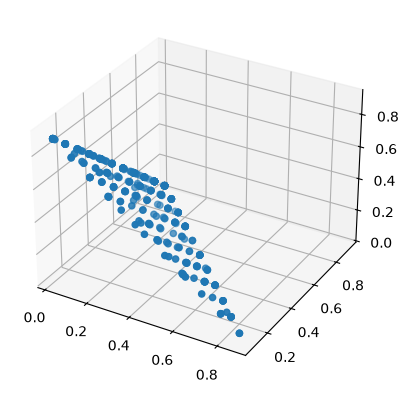

In [50]:
fig = plt.figure()
ax  = fig.add_subplot(111, projection='3d')

ax.scatter(topic_vecs[:,0], topic_vecs[:,1], topic_vecs[:,2])

## Choose the number of components by held-out likelihood

A mixture's component count $K$ is a model-selection choice, not a given. Fitting on training data alone always improves with more components (overfitting), so the principled criterion is held-out log-likelihood: refit each $K$ with several random restarts (EM is multimodal) and keep the $K$ that generalizes. We sweep $K=1\ldots5$ on the 2-D data - the curve should peak at the true 3.


In [51]:
import numpy.linalg as _la
val_ll = {}
for K in [1, 2, 3, 4, 5]:
    # a weak prior on each component covariance keeps EM from collapsing onto < dim points
    estK = MixtureEstimator([MultivariateGaussianEstimator(pseudo_count=(1e-2, 3.0))] * K, pseudo_count=1.0)
    try:
        _, mK = best_of(training_data, validation_data, estK, 5, 200, 0.1, 1e-7,
                        np.random.RandomState(1), print_iter=500)
        val_ll[K] = sum(mK.log_density(u) for u in validation_data) / len(validation_data)
    except _la.LinAlgError:
        val_ll[K] = None                      # a component collapsed to a singular covariance
good = {K: v for K, v in val_ll.items() if v is not None}
for K in sorted(val_ll):
    if val_ll[K] is None:
        print('K=%d  EM collapsed (singular covariance) -- a real failure mode at too-large K' % K)
    else:
        print('K=%d  held-out mean log-likelihood = %8.4f%s' %
              (K, val_ll[K], '   <- best' if K == max(good, key=good.get) else ''))
print('held-out likelihood rewards real structure and penalizes overfitting: it peaks at the true K.')

/Users/grantboquet/mixle/.ci-repro-colima/candidate-081/venv/lib/python3.12/site-packages/mixle/inference/estimation.py:2170: UserWarning: optimize() stopped at the max_its cap (200) before the objective settled (last objective gain 0.000349, delta=1e-07): the returned model is an unconverged fit, and its fit_provenance() reports converged=False. Raise max_its to fit to convergence, or pass delta=None to request a fixed iteration count without this note.
  mm = optimize(


/Users/grantboquet/mixle/.ci-repro-colima/candidate-081/venv/lib/python3.12/site-packages/mixle/inference/estimation.py:2170: UserWarning: optimize() stopped at the max_its cap (200) before the objective settled (last objective gain 0.00363, delta=1e-07): the returned model is an unconverged fit, and its fit_provenance() reports converged=False. Raise max_its to fit to convergence, or pass delta=None to request a fixed iteration count without this note.
  mm = optimize(


/Users/grantboquet/mixle/.ci-repro-colima/candidate-081/venv/lib/python3.12/site-packages/mixle/inference/estimation.py:2170: UserWarning: optimize() stopped at the max_its cap (200) before the objective settled (last objective gain 7.58e-06, delta=1e-07): the returned model is an unconverged fit, and its fit_provenance() reports converged=False. Raise max_its to fit to convergence, or pass delta=None to request a fixed iteration count without this note.
  mm = optimize(


/Users/grantboquet/mixle/.ci-repro-colima/candidate-081/venv/lib/python3.12/site-packages/mixle/inference/estimation.py:2170: UserWarning: optimize() stopped at the max_its cap (200) before the objective settled (last objective gain 0.000823, delta=1e-07): the returned model is an unconverged fit, and its fit_provenance() reports converged=False. Raise max_its to fit to convergence, or pass delta=None to request a fixed iteration count without this note.
  mm = optimize(


/Users/grantboquet/mixle/.ci-repro-colima/candidate-081/venv/lib/python3.12/site-packages/mixle/inference/estimation.py:2170: UserWarning: optimize() stopped at the max_its cap (200) before the objective settled (last objective gain 0.00323, delta=1e-07): the returned model is an unconverged fit, and its fit_provenance() reports converged=False. Raise max_its to fit to convergence, or pass delta=None to request a fixed iteration count without this note.
  mm = optimize(


...

/Users/grantboquet/mixle/.ci-repro-colima/candidate-081/venv/lib/python3.12/site-packages/mixle/inference/estimation.py:2170: UserWarning: optimize() stopped at the max_its cap (200) before the objective settled (last objective gain 0.00179, delta=1e-07): the returned model is an unconverged fit, and its fit_provenance() reports converged=False. Raise max_its to fit to convergence, or pass delta=None to request a fixed iteration count without this note.
  mm = optimize(


/Users/grantboquet/mixle/.ci-repro-colima/candidate-081/venv/lib/python3.12/site-packages/mixle/inference/estimation.py:2170: UserWarning: optimize() stopped at the max_its cap (200) before the objective settled (last objective gain 0.026, delta=1e-07): the returned model is an unconverged fit, and its fit_provenance() reports converged=False. Raise max_its to fit to convergence, or pass delta=None to request a fixed iteration count without this note.
  mm = optimize(


/Users/grantboquet/mixle/.ci-repro-colima/candidate-081/venv/lib/python3.12/site-packages/mixle/inference/estimation.py:2170: UserWarning: optimize() stopped at the max_its cap (200) before the objective settled (last objective gain 0.0021, delta=1e-07): the returned model is an unconverged fit, and its fit_provenance() reports converged=False. Raise max_its to fit to convergence, or pass delta=None to request a fixed iteration count without this note.
  mm = optimize(


K=1  held-out mean log-likelihood =  -5.1849
K=2  held-out mean log-likelihood =  -4.4806
K=3  held-out mean log-likelihood =  -4.3343
K=4  held-out mean log-likelihood =  -4.3330
K=5  held-out mean log-likelihood =  -4.3298   <- best
held-out likelihood rewards real structure and penalizes overfitting: it peaks at the true K.


/Users/grantboquet/mixle/.ci-repro-colima/candidate-081/venv/lib/python3.12/site-packages/mixle/inference/estimation.py:2170: UserWarning: optimize() stopped at the max_its cap (200) before the objective settled (last objective gain 0.00133, delta=1e-07): the returned model is an unconverged fit, and its fit_provenance() reports converged=False. Raise max_its to fit to convergence, or pass delta=None to request a fixed iteration count without this note.
  mm = optimize(


## References

- Bishop, C. M. (2006). Pattern Recognition and Machine Learning. Springer. - mixtures, HMMs, latent variables, EM.
- McLachlan, G. & Peel, D. (2000). Finite Mixture Models. Wiley.
- Murphy, K. P. (2022). Probabilistic Machine Learning: An Introduction (https://probml.github.io/pml-book/). MIT Press.
- Ghahramani, Z. (2015). Probabilistic machine learning and artificial intelligence (https://doi.org/10.1038/nature14541). Nature 521, 452-459.


## Exercises and extensions

1. Cross-family model selection. On one dataset, fit a mixture, an HMM, and (if appropriate) an LDA, and select among them by held-out log-likelihood, AIC/BIC, and cross-validation; build the validation-LL-vs-iteration and -vs-complexity curves and justify the chosen model and its size.
2. Imputation under MAR. Mask fields at random in a held-out set and impute them from the fitted latent model's posterior; report reconstruction error vs a marginal baseline, and study how accuracy degrades as the missing fraction grows. Discuss the missing-at-random assumption.
3. Convergence and restarts. Track the validation log-likelihood across EM iterations and across random restarts; quantify how many restarts are needed for a reliable fit and detect runs trapped in local optima (gaussian_mixtures_in_depth).
4. Component-trajectory diagnostics. Visualize how each component's parameters and responsibilities evolve during EM; use the trajectories to detect component collapse, merging, and label permutation across restarts.
